In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df_events = pd.read_csv("/Users/victoriayuzova/Data-Science-Projects/ba-events-recommender/data/raw/2026-03-16/03_events.csv")
df_events.head()

,url,homepage_url,page_type,title,summary,category,start_date,start_time,venue,price,is_free,tags,confidence,run_date,extracted_at
0,https://complejoteatral.gob.ar/agenda?fecha=16...,https://complejoteatral.gob.ar/,listing,Agenda | Complejo Teatral de Buenos Aires,Listing of theatrical events around 16 March 2...,theatre,NaN,NaN,NaN,NaN,NaN,"['teatro', 'agenda', 'temporada internacional'...",0.80,2026-03-16,2026-03-16T11:43:12+00:00
1,https://complejoteatral.gob.ar/pdf/temporada20...,https://complejoteatral.gob.ar/,pdf,NaN,NaN,other,NaN,NaN,NaN,NaN,NaN,[],0.30,2026-03-16,2026-03-16T11:43:12+00:00
2,https://complejoteatral.gob.ar/ver/GERALD-CLAY...,https://complejoteatral.gob.ar/,event_detail,GERALD CLAYTON TRIO,Comienza el ciclo de jazz en el Teatro San Mar...,music,2026-03-17,20:00,"Teatro San Martín, Sala Martín Coronado","Platea Filas 2 a 5 $85.000, Platea Filas 6 a 2...",False,"['jazz', 'Gerald Clayton', 'Trio', 'Teatro San...",0.95,2026-03-16,2026-03-16T11:43:12+00:00
3,https://complejoteatral.gob.ar/ver/la_gaviota,https://complejoteatral.gob.ar/,event_detail,La Gaviota,"Obra de teatro de Antón Chéjov, dirigida por R...",theatre,NaN,NaN,"Teatro San Martín, Sala Casacuberta","Platea $21.000, Miércoles $12.000",False,"['teatro', 'obra', 'Antón Chéjov', 'Rubén Szuc...",0.95,2026-03-16,2026-03-16T11:43:12+00:00
4,https://complejoteatral.gob.ar/ver/jazz_buenos...,https://complejoteatral.gob.ar/,event_detail,Jazz Buenos Aires,Ciclo de nueve conciertos de Jazz at Lincoln C...,music,2026-03-17,20:00,"Teatro San Martín, Sala Martín Coronado","Platea Filas 2 a 5 $85.000, Platea Filas 6 a 2...",False,"['jazz', 'concierto', 'música', 'Jazz at Linco...",0.95,2026-03-16,2026-03-16T11:43:12+00:00


In [6]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           103 non-null    object 
 1   homepage_url  103 non-null    object 
 2   page_type     103 non-null    object 
 3   title         45 non-null     object 
 4   summary       45 non-null     object 
 5   category      103 non-null    object 
 6   start_date    33 non-null     object 
 7   start_time    33 non-null     object 
 8   venue         44 non-null     object 
 9   price         18 non-null     object 
 10  is_free       22 non-null     object 
 11  tags          103 non-null    object 
 12  confidence    103 non-null    float64
 13  run_date      103 non-null    object 
 14  extracted_at  103 non-null    object 
dtypes: float64(1), object(14)
memory usage: 12.2+ KB


In [7]:
df_clean = df_events[
    (df_events["page_type"]=='event_detail')&
    (df_events["confidence"]>=0.7)&
    (df_events["summary"].notna())
].reset_index(drop=True)

df_clean.shape

(36, 15)

In [8]:
df_clean['category'].value_counts()

category
theatre       9
cinema        7
exhibition    7
talk          7
workshop      3
music         2
dance         1
Name: count, dtype: int64

In [11]:
user_ratings = pd.read_csv('/Users/victoriayuzova/Data-Science-Projects/ba-events-recommender/data/processed/user_ratings.csv')
user_ratings.head()

,url,title,category,is_free,summary,liked
0,https://complejoteatral.gob.ar/ver/GERALD-CLAY...,GERALD CLAYTON TRIO,music,False,Comienza el ciclo de jazz en el Teatro San Mar...,0
1,https://complejoteatral.gob.ar/ver/la_gaviota,La Gaviota,theatre,False,"Obra de teatro de Antón Chéjov, dirigida por R...",1
2,https://complejoteatral.gob.ar/ver/jazz_buenos...,Jazz Buenos Aires,music,False,Ciclo de nueve conciertos de Jazz at Lincoln C...,1
3,https://complejoteatral.gob.ar/ver/los-pilares...,LOS PILARES DE LA SOCIEDAD,theatre,False,Obra de teatro de Henrik Ibsen que denuncia la...,1
4,https://complejoteatral.gob.ar/ver/invasiones-1,INVASIONES I,theatre,False,Invasiones I: No Bombardeen Buenos Aires es un...,0


In [ ]:
merged = df_clean.merge(user_ratings[['url','liked']], on='url', how='left')
print(merged['liked'].notna().sum())

In [16]:
print(merged['category'].value_counts())
print   (f"\nLike rate: {merged['liked'].mean():.2%}")

category
theatre       9
cinema        7
exhibition    7
talk          7
workshop      3
music         2
dance         1
Name: count, dtype: int64

Like rate: 27.78%


In [21]:
merged = merged[['url', 'title', 'summary', 'category', 'venue', 'is_free', 'tags','confidence' ,'homepage_url', 'liked']]

In [22]:
df_clean = merged.copy()
df_clean.to_csv('/Users/victoriayuzova/Data-Science-Projects/ba-events-recommender/data/processed/events_clean.csv', index=False)

print(df_clean.shape)



(36, 10)


In [23]:
df_clean.head()

,url,title,summary,category,venue,is_free,tags,confidence,homepage_url,liked
0,https://complejoteatral.gob.ar/ver/GERALD-CLAY...,GERALD CLAYTON TRIO,Comienza el ciclo de jazz en el Teatro San Mar...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'Gerald Clayton', 'Trio', 'Teatro San...",0.95,https://complejoteatral.gob.ar/,0
1,https://complejoteatral.gob.ar/ver/la_gaviota,La Gaviota,"Obra de teatro de Antón Chéjov, dirigida por R...",theatre,"Teatro San Martín, Sala Casacuberta",False,"['teatro', 'obra', 'Antón Chéjov', 'Rubén Szuc...",0.95,https://complejoteatral.gob.ar/,1
2,https://complejoteatral.gob.ar/ver/jazz_buenos...,Jazz Buenos Aires,Ciclo de nueve conciertos de Jazz at Lincoln C...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'concierto', 'música', 'Jazz at Linco...",0.95,https://complejoteatral.gob.ar/,1
3,https://complejoteatral.gob.ar/ver/los-pilares...,LOS PILARES DE LA SOCIEDAD,Obra de teatro de Henrik Ibsen que denuncia la...,theatre,"Teatro Presidente Alvear, Av. Corrientes 1659",False,"['Henrik Ibsen', 'teatro', 'obra', 'funciones ...",0.95,https://complejoteatral.gob.ar/,1
4,https://complejoteatral.gob.ar/ver/invasiones-1,INVASIONES I,Invasiones I: No Bombardeen Buenos Aires es un...,theatre,"Teatro San Martín, Sala Martín Coronado",False,"['musical', 'opera rock', 'Elena Roger', 'Char...",0.95,https://complejoteatral.gob.ar/,0


In [27]:

# Combine summary and tags into one text field
df_clean['text'] = df_clean['summary'] + ' ' + df_clean['tags'].apply(lambda x: ' '.join(x))

# Build TF-IDF matrix
tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df_clean['text'])

print(tfidf_matrix.shape)

(36, 100)


In [29]:
df_clean.head()

,url,title,summary,category,venue,is_free,tags,confidence,homepage_url,liked,text
0,https://complejoteatral.gob.ar/ver/GERALD-CLAY...,GERALD CLAYTON TRIO,Comienza el ciclo de jazz en el Teatro San Mar...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'Gerald Clayton', 'Trio', 'Teatro San...",0.95,https://complejoteatral.gob.ar/,0,Comienza el ciclo de jazz en el Teatro San Mar...
1,https://complejoteatral.gob.ar/ver/la_gaviota,La Gaviota,"Obra de teatro de Antón Chéjov, dirigida por R...",theatre,"Teatro San Martín, Sala Casacuberta",False,"['teatro', 'obra', 'Antón Chéjov', 'Rubén Szuc...",0.95,https://complejoteatral.gob.ar/,1,"Obra de teatro de Antón Chéjov, dirigida por R..."
2,https://complejoteatral.gob.ar/ver/jazz_buenos...,Jazz Buenos Aires,Ciclo de nueve conciertos de Jazz at Lincoln C...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'concierto', 'música', 'Jazz at Linco...",0.95,https://complejoteatral.gob.ar/,1,Ciclo de nueve conciertos de Jazz at Lincoln C...
3,https://complejoteatral.gob.ar/ver/los-pilares...,LOS PILARES DE LA SOCIEDAD,Obra de teatro de Henrik Ibsen que denuncia la...,theatre,"Teatro Presidente Alvear, Av. Corrientes 1659",False,"['Henrik Ibsen', 'teatro', 'obra', 'funciones ...",0.95,https://complejoteatral.gob.ar/,1,Obra de teatro de Henrik Ibsen que denuncia la...
4,https://complejoteatral.gob.ar/ver/invasiones-1,INVASIONES I,Invasiones I: No Bombardeen Buenos Aires es un...,theatre,"Teatro San Martín, Sala Martín Coronado",False,"['musical', 'opera rock', 'Elena Roger', 'Char...",0.95,https://complejoteatral.gob.ar/,0,Invasiones I: No Bombardeen Buenos Aires es un...


In [30]:
print(tfidf_matrix.shape)
print(df_clean.shape)
print(df_clean['liked'].value_counts())

(36, 100)
(36, 11)
liked
0    26
1    10
Name: count, dtype: int64


In [ ]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)

In [33]:
liked_indices = df_clean[df_clean['liked']==True].index.tolist()

scores = similarity_matrix[liked_indices].mean(axis=0)

df_clean['rec_score'] = scores

recommendations = (df_clean[df_clean['liked'] == 0]
                   .sort_values('rec_score', ascending=False)
                   [['title', 'category', 'is_free', 'rec_score']]
                   .head(10))

print(recommendations)


                                            title    category is_free  \
21             Chiachio & Giannone: Hacer familia  exhibition    True   
15       Tercer ojo Colección Costantini en Malba  exhibition     NaN   
9                                        NUMANCIA     theatre   False   
6                                     Baco polaco     theatre   False   
33  Trajetos brasileiros na arte latino-americana  exhibition   False   
0                             GERALD CLAYTON TRIO       music   False   
24          Recorridos abiertos por Cuerpo textil  exhibition   False   
7               FESTIVAL EL TORNILLO - II EDICIÓN     theatre     NaN   
23                                  Hitchcock x 4      cinema     NaN   
5                                         PARAÍSO     theatre   False   

    rec_score  
21   0.311179  
15   0.307001  
9    0.301849  
6    0.281833  
33   0.277752  
0    0.267276  
24   0.264512  
7    0.263160  
23   0.260916  
5    0.246884  


In [ ]:
from sklearn.linear_model import LogisticRegression

X = tfidf_matrix 
y = df_clean['liked']

model = LogisticRegression()
model.fit(X, y)

# Predict probability of liking each event
df_clean['like_probability'] = model.predict_proba(X)[:, 1]

In [36]:
df_clean.sort_values('like_probability', ascending=False, inplace=True)
df_clean

,url,title,summary,category,venue,is_free,tags,confidence,homepage_url,liked,text,rec_score,like_probability
32,https://malba.org.ar/inauguracion-olga-de-amaral/,Olga de Amaral. Cuerpo Textil,Retrospective exhibition dedicated to Colombia...,exhibition,"Malba, Av. Figueroa Alcorta 3415, Buenos Aires",NaN,"['Olga de Amaral', 'textile art', 'retrospecti...",0.90,https://malba.org.ar/,1,Retrospective exhibition dedicated to Colombia...,0.131580,0.441837
17,https://malba.org.ar/evento/fernanda-laguna-mi...,Fernanda Laguna: Mi corazón es un imán (1992-2...,Exposición retrospectiva de la obra de Fernand...,exhibition,"MALBA, Av. Figueroa Alcorta 3415, Buenos Aires...",NaN,"['exposiciones', 'exposiciones destacadas', 'a...",0.95,https://malba.org.ar/,1,Exposición retrospectiva de la obra de Fernand...,0.323379,0.438050
1,https://complejoteatral.gob.ar/ver/la_gaviota,La Gaviota,"Obra de teatro de Antón Chéjov, dirigida por R...",theatre,"Teatro San Martín, Sala Casacuberta",False,"['teatro', 'obra', 'Antón Chéjov', 'Rubén Szuc...",0.95,https://complejoteatral.gob.ar/,1,"Obra de teatro de Antón Chéjov, dirigida por R...",0.267695,0.399828
3,https://complejoteatral.gob.ar/ver/los-pilares...,LOS PILARES DE LA SOCIEDAD,Obra de teatro de Henrik Ibsen que denuncia la...,theatre,"Teatro Presidente Alvear, Av. Corrientes 1659",False,"['Henrik Ibsen', 'teatro', 'obra', 'funciones ...",0.95,https://complejoteatral.gob.ar/,1,Obra de teatro de Henrik Ibsen que denuncia la...,0.339769,0.392251
2,https://complejoteatral.gob.ar/ver/jazz_buenos...,Jazz Buenos Aires,Ciclo de nueve conciertos de Jazz at Lincoln C...,music,"Teatro San Martín, Sala Martín Coronado",False,"['jazz', 'concierto', 'música', 'Jazz at Linco...",0.95,https://complejoteatral.gob.ar/,1,Ciclo de nueve conciertos de Jazz at Lincoln C...,0.226482,0.384903
19,https://malba.org.ar/evento/anima-y-animus-en-...,Ánima y ánimus en Carl G. Jung: el desarrollo ...,Seminario intensivo presencial y virtual que a...,talk,"Auditorio, MALBA, Av. Figueroa Alcorta 3415, B...",False,"['Agenda', 'Cursos', 'Literatura', 'Actividade...",0.95,https://malba.org.ar/,1,Seminario intensivo presencial y virtual que a...,0.304561,0.384847
16,https://malba.org.ar/evento/olga-de-amaral-cue...,Olga de Amaral: Cuerpo textil,Exposición que revisa la práctica artística de...,exhibition,"MALBA, Av. Figueroa Alcorta 3415, Buenos Aires",NaN,"['exposiciones', 'exposiciones destacadas', 'a...",0.95,https://malba.org.ar/,1,Exposición que revisa la práctica artística de...,0.320749,0.372860
22,https://malba.org.ar/evento/el-cuerpo-del-colo...,El cuerpo del color: el ikat tridimensional de...,Conferencia por Roxana Amarilla sobre la técni...,talk,"Biblioteca MALBA, Av. Figueroa Alcorta 3415, B...",True,"['Olga de Amaral', 'ikat', 'textiles', 'confer...",0.95,https://malba.org.ar/,1,Conferencia por Roxana Amarilla sobre la técni...,0.224334,0.370451
26,https://malba.org.ar/evento/belleza-y-felicida...,Belleza y Felicidad Autobiografía de una amistad,"Presentación de libro con Fernanda Laguna, Cec...",talk,Biblioteca,True,"['Presentación de libro', 'Actividad gratuita ...",0.95,https://malba.org.ar/,1,"Presentación de libro con Fernanda Laguna, Cec...",0.287961,0.368612
18,https://malba.org.ar/evento/fernanda-laguna-mi...,Conferencia inaugural Fernanda Laguna Mi coraz...,La conferencia inaugural acompañará la apertur...,talk,"Auditorio, MALBA, Av. Figueroa Alcorta 3415, B...",NaN,"['Fernanda Laguna', 'conferencia', 'retrospect...",0.95,https://malba.org.ar/,1,La conferencia inaugural acompañará la apertur...,0.332623,0.364280


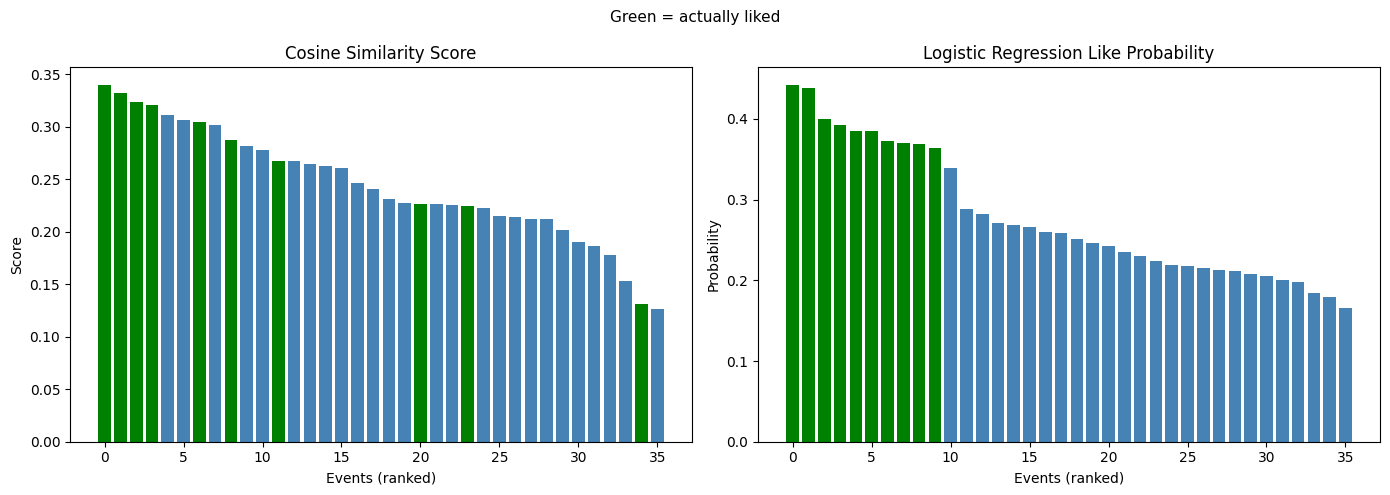

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: rec_score
df_plot = df_clean.sort_values('rec_score', ascending=False).reset_index(drop=True)
axes[0].bar(range(len(df_plot)), df_plot['rec_score'], 
            color=['green' if x == 1 else 'steelblue' for x in df_plot['liked']])
axes[0].set_title('Cosine Similarity Score')
axes[0].set_xlabel('Events (ranked)')
axes[0].set_ylabel('Score')

# Plot 2: like_probability
df_plot2 = df_clean.sort_values('like_probability', ascending=False).reset_index(drop=True)
axes[1].bar(range(len(df_plot2)), df_plot2['like_probability'],
            color=['green' if x == 1 else 'steelblue' for x in df_plot2['liked']])
axes[1].set_title('Logistic Regression Like Probability')
axes[1].set_xlabel('Events (ranked)')
axes[1].set_ylabel('Probability')

plt.suptitle('Green = actually liked', fontsize=11)
plt.tight_layout()
plt.show()